In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\PC\OneDrive - National Economics University\Máy tính\Fraud-Detection


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

from src.config import PROCESSED_DATA_DIR
from src.train import train_all_models, get_model_predictions
from src.evaluate import (
    get_confusion_matrix_df,
    get_classification_report_df,
    get_logistic_coefficients,
    get_tree_feature_importance,
    summarize_predictions,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
df = pd.read_excel(PROCESSED_DATA_DIR / "model_data.xlsx")
artifacts = train_all_models(df)

print("Best model on test:", artifacts["best_model_name"])
display(artifacts["test_summary"].round(4))

Best model on test: SVM


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Split
0,SVM,0.5775,0.3723,0.7692,0.5018,0.6985,0.4441,Test
1,XGBoost,0.6687,0.4392,0.7143,0.5439,0.6967,0.4663,Test
2,LightGBM,0.6474,0.4161,0.6813,0.5167,0.6965,0.4692,Test
3,ANN,0.6778,0.4051,0.3516,0.3765,0.6610,0.3813,Test
4,Logistic Regression,0.7143,0.4444,0.1319,0.2034,0.6682,0.4032,Test


In [4]:
y_test = artifacts["y_test"]
feature_cols = artifacts["feature_cols"]
final_models = artifacts["final_models"]

model_objects_for_test = final_models

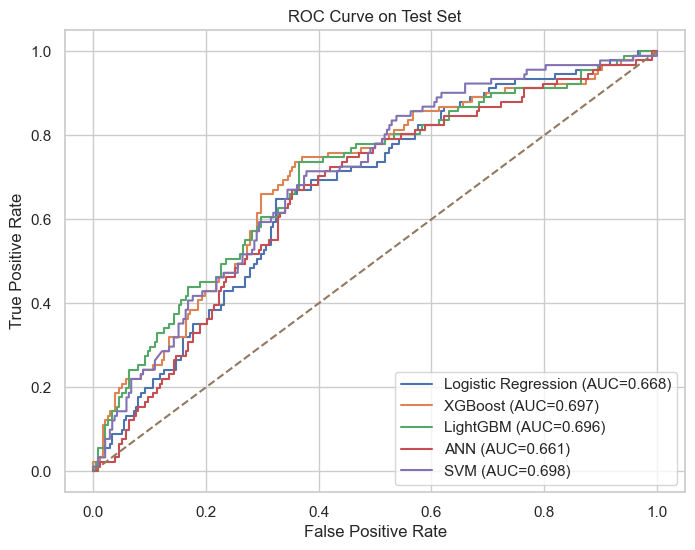

In [5]:
plt.figure(figsize=(8, 6))

for model_name, (model_obj, X_input) in model_objects_for_test.items():
    _, y_prob = get_model_predictions(model_obj, X_input)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

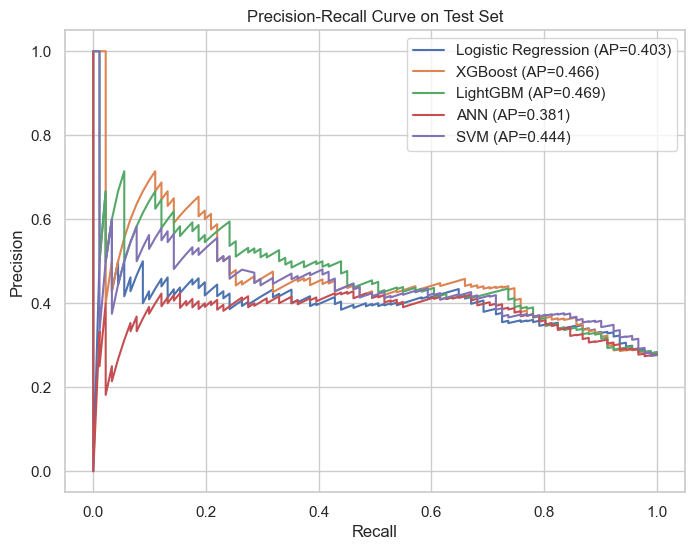

In [6]:
plt.figure(figsize=(8, 6))

for model_name, (model_obj, X_input) in model_objects_for_test.items():
    _, y_prob = get_model_predictions(model_obj, X_input)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve on Test Set")
plt.legend()
plt.show()

,Predicted_0,Predicted_1
Actual_0,120,118
Actual_1,21,70


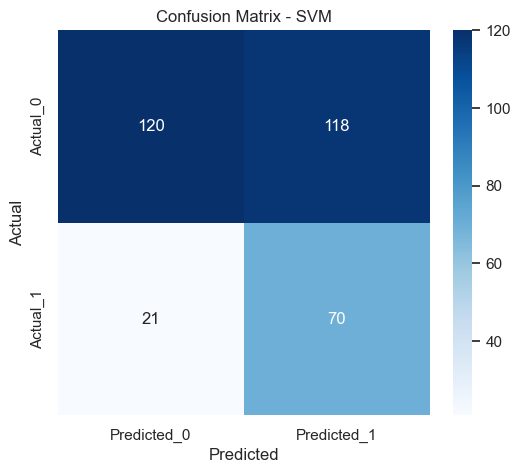

In [7]:
best_test_model_name = artifacts["best_model_name"]
best_test_model, best_test_X = model_objects_for_test[best_test_model_name]

best_y_pred, best_y_prob = get_model_predictions(best_test_model, best_test_X)

cm_df = get_confusion_matrix_df(y_test, best_y_pred)
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_test_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
report_df = get_classification_report_df(y_test, best_y_pred)
display(report_df)

,precision,recall,f1-score,support
0,0.851064,0.504202,0.633245,238.000000
1,0.372340,0.769231,0.501792,91.000000
accuracy,0.577508,0.577508,0.577508,0.577508
macro avg,0.611702,0.636716,0.567519,329.000000
weighted avg,0.718651,0.577508,0.596886,329.000000


In [9]:
if best_test_model_name == "Logistic Regression":
    coef_df = get_logistic_coefficients(best_test_model, feature_cols)
    display(coef_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df, x="Coefficient", y="Feature")
    plt.title("Logistic Regression Coefficients")
    plt.show()

In [10]:
if best_test_model_name in ["XGBoost", "LightGBM"]:
    importance_df = get_tree_feature_importance(best_test_model, feature_cols)
    display(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Feature Importance - {best_test_model_name}")
    plt.show()

In [11]:
test_df = artifacts["test_df"].copy()
prediction_df = summarize_predictions(
    df_test=test_df,
    y_true=y_test,
    y_pred=best_y_pred,
    y_prob=best_y_prob,
)

display(prediction_df.head(20))

,CP,Năm,Actual,Predicted,Predicted_Prob
0,HAF,2023,1,1,0.705471
1,DP2,2023,0,1,0.670361
2,PIT,2023,0,1,0.658717
3,SDA,2023,1,1,0.654963
4,SPC,2023,1,1,0.651804
5,DPC,2023,0,1,0.650606
6,DXS,2023,0,1,0.641913
7,ECI,2023,0,1,0.635534
8,CIG,2023,1,1,0.632159
9,SDU,2023,1,1,0.621591
